In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.datasets import make_circles

In [11]:
X, y = make_circles(n_samples=300, noise=0.1, factor=0.4, random_state=42)


In [12]:
len(df[0])

300

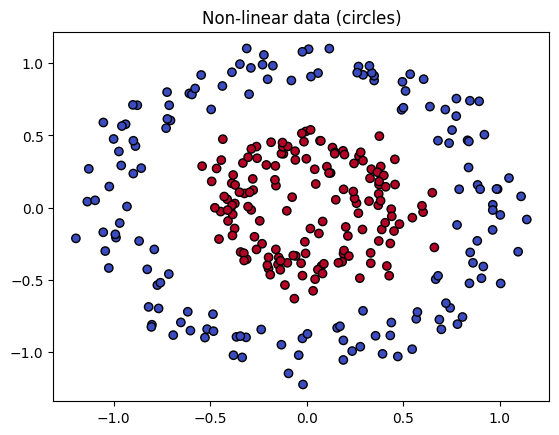

In [13]:
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolors='k')
plt.title("Non-linear data (circles)")
plt.show()

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [15]:
kernels = ['linear', 'poly', 'rbf']
models = {}

for k in kernels:
    model = SVC(kernel=k, random_state=42)
    model.fit(X_train_scaled, y_train)
    models[k] = model
    acc = accuracy_score(y_test, model.predict(X_test_scaled))
    print(f"{k} kernel accuracy: {acc:.4f}")

linear kernel accuracy: 0.5500
poly kernel accuracy: 0.7000
rbf kernel accuracy: 1.0000


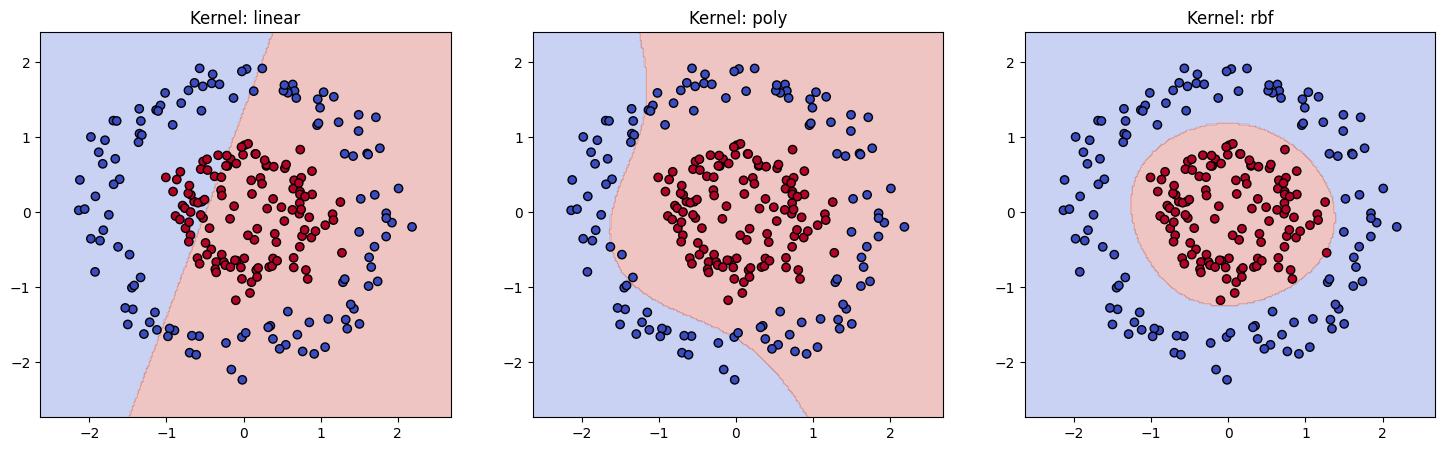

In [16]:
def plot_boundary(model, X, y, title, ax):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolors='k')
    ax.set_title(title)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, k in zip(axes, kernels):
    plot_boundary(models[k], X_train_scaled, y_train, f"Kernel: {k}", ax)
plt.show()

In [17]:
svm_rbf = SVC(kernel='rbf', gamma=0.5, random_state=42)
svm_rbf.fit(X_train_scaled, y_train)
print("RBF (gamma=0.5) accuracy:", accuracy_score(y_test, svm_rbf.predict(X_test_scaled)))

RBF (gamma=0.5) accuracy: 1.0
